Name: Hissah Alkharboush

Fast Food Marketing Campaign A/B Test

Overveiw

The primary objective is to assist the fast-food chain in making a data-driven decision to select the most successful marketing campaign among three available options, ensuring the highest possible sales upon the official launch of the new product.

Goal:
Evaluate A/B testing results and decide which marketing strategy works the best

I will start with EDA :

In [13]:
#import the libraries
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

In [14]:
#import data
data = "WA_Marketing-Campaign.csv"

In [20]:
#Using a data as dataset
food_marketing = pd.read_csv(data)
food_marketing.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


In [17]:
food_marketing.describe()

,MarketID,LocationID,AgeOfStore,Promotion,week,SalesInThousands
count,548.000000,548.000000,548.000000,548.000000,548.000000,548.000000
mean,5.715328,479.656934,8.503650,2.029197,2.500000,53.466204
std,2.877001,287.973679,6.638345,0.810729,1.119055,16.755216
min,1.000000,1.000000,1.000000,1.000000,1.000000,17.340000
25%,3.000000,216.000000,4.000000,1.000000,1.750000,42.545000
50%,6.000000,504.000000,7.000000,2.000000,2.500000,50.200000
75%,8.000000,708.000000,12.000000,3.000000,3.250000,60.477500
max,10.000000,920.000000,28.000000,3.000000,4.000000,99.650000


Try ..

In [22]:
food_marketing.groupby(['MarketSize']).mean()

,MarketID,LocationID,AgeOfStore,Promotion,week,SalesInThousands
MarketSize,,,,,,
Large,6.333333,544.357143,7.142857,1.952381,2.5,70.116726
Medium,5.862500,493.550000,8.787500,2.062500,2.5,43.985344
Small,3.200000,224.400000,10.800000,2.066667,2.5,57.409333


.....

- Create first hypothesis from dataset, finding which promotion get a high impact by calculate the mean of sales for each promotion

In [27]:
promotion_mean = food_marketing.groupby('Promotion')['SalesInThousands'].mean()
promotion_mean

Promotion
1    58.099012
2    47.329415
3    55.364468
Name: SalesInThousands, dtype: float64

Using visualization to present the hypothesis in a different way:

C:\Users\96654\AppData\Local\Temp\ipykernel_31452\4008060825.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=promotion_mean.index, y=promotion_mean.values, palette='viridis')


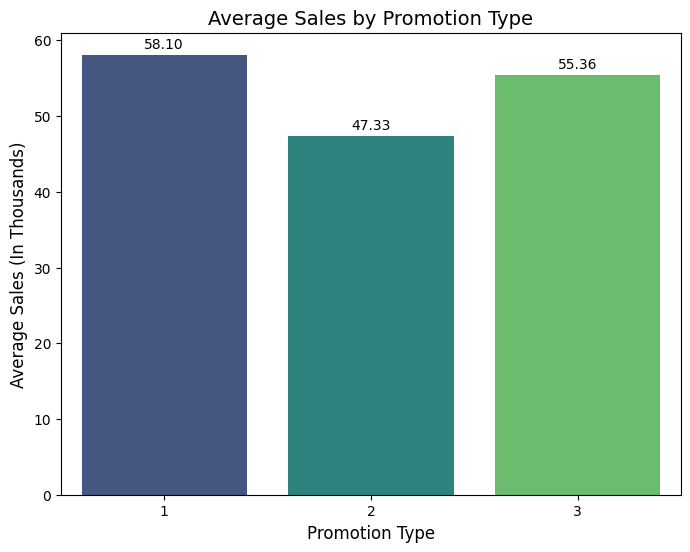

In [28]:
plt.figure(figsize=(8, 6))
sns.barplot(x=promotion_mean.index, y=promotion_mean.values, palette='viridis')

plt.title('Average Sales by Promotion Type', fontsize=14)
plt.xlabel('Promotion Type', fontsize=12)
plt.ylabel('Average Sales (In Thousands)', fontsize=12)

for i, value in enumerate(promotion_mean.values):
    plt.text(i, value + 0.5, f'{value:.2f}', ha='center', va='bottom')

plt.show()

The diagram shows that the first promotion has a higher mean than the others. To confirm this hypothesis, we should validate it using CDA (Confirmatory Data Analysis)

In [ ]:
promo1 = food_marketing[food_marketing['Promotion'] == 1]['SalesInThousands']
promo2 = food_marketing[food_marketing['Promotion'] == 2]['SalesInThousands']
promo3 = food_marketing[food_marketing['Promotion'] == 3]['SalesInThousands']

f_stat, p_value = stats.f_oneway(promo1, promo2, promo3)

#print(f"F-Statistic: {f_stat:.4f}")
#print(f"P-Value: {p_value:.4f}")

alpha = 0.05

if p_value < alpha:
    # Reject the null hypothesis because the difference is statistically significant
    print("Result: There is a statistically significant difference between the campaigns.")
else:
    # Fail to reject the null hypothesis because the difference is not significant
    print("Result: There is no statistically significant difference between the campaigns.")

F-Statistic: 21.9535
P-Value: 0.0000
Result: There is a statistically significant difference between the campaigns.
